In [ ]:
import pandas as pd

# Reemplaza 'HISTORICO_ESTANDAR_PLANES.xlsx' si tu archivo tiene otro nombre
excel_file_path = '/content/HISTORICO_ESTANDAR_PLANES.xlsx'
df = pd.read_excel(excel_file_path)

# Muestra las primeras 5 filas del DataFrame para verificar que se cargó correctamente
display(df.head())

,Marca temporal,LLave,Plan de estudios,Facultad,Nivel,Seleccione la categoría de su consulta,¿Con la información que se le ha expuesto se ha resuelto su consulta?,Por favor indique el detalle de su consulta,RESPUESTA DEL CASO,ESTADO SOLICITUD,SEMESTRE,PLAN_ESTANDAR
0,2022-07-18 15:34:02,Estudiante_1,Maestría en Ingeniería Eléctrica,Facultad de Ingeniería,Posgrado,Carnetizacin,No,Ayuda no se como inscribir asignaturas y nadie...,A continuación adjunto instructivo xxxxxxxx,Gestionado,2022_2,Maestría en Ingeniería Eléctrica
1,2022-07-18 15:34:59,Estudiante_2,Ingeniería electrónica,Facultad de Ingeniería,Pregrado,Calendario acadmico,No,Donde puedo ver el calendario académico?,El calendario ya se encuentra habilitado en el...,Gestionado,2022_2,INGENIERÍA ELECTRÓNICA
2,2022-07-18 15:36:25,Estudiante_1,Ingeniería eléctrica,Facultad de Ingeniería,Pregrado,Carnetizacin,Sí,NaN,NaN,No se requirió gestión por DRM,2022_2,INGENIERÍA ELÉCTRICA
3,2022-07-18 15:38:37,Estudiante_1,Ingeniería electrónica,Facultad de Ingeniería,Posgrado,Gestin Econmica - Informacin general,Sí,NaN,NaN,No se requirió gestión por DRM,2022_2,INGENIERÍA ELECTRÓNICA
4,2022-07-18 16:00:02,Estudiante_5,Sociología,Facultad de Ciencias Humanas,Pregrado,Carnetizacin,No,Quiero mi carné nuevo,\n\nPara la expedición de carnet por primera v...,Gestionado,2022_2,SOCIOLOGÍA


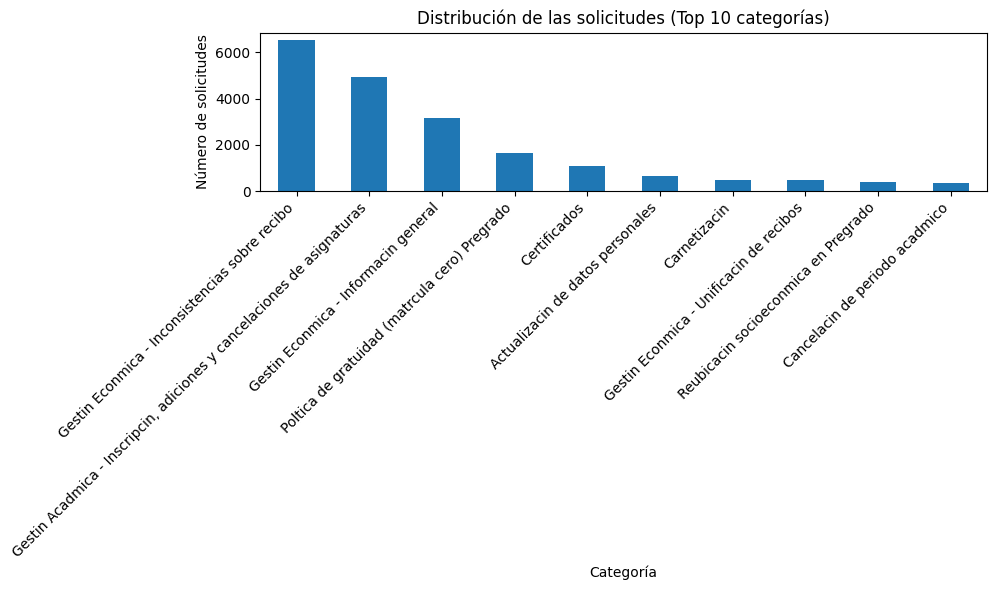

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Contar categorías
counts = df['Seleccione la categoría de su consulta'].value_counts()

# Tomar solo top 10
top_counts = counts.head(10)

plt.figure(figsize=(10,6))
top_counts.plot(kind='bar')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Categoría')
plt.ylabel('Número de solicitudes')
plt.title('Distribución de las solicitudes (Top 10 categorías)')

plt.tight_layout()
plt.show()

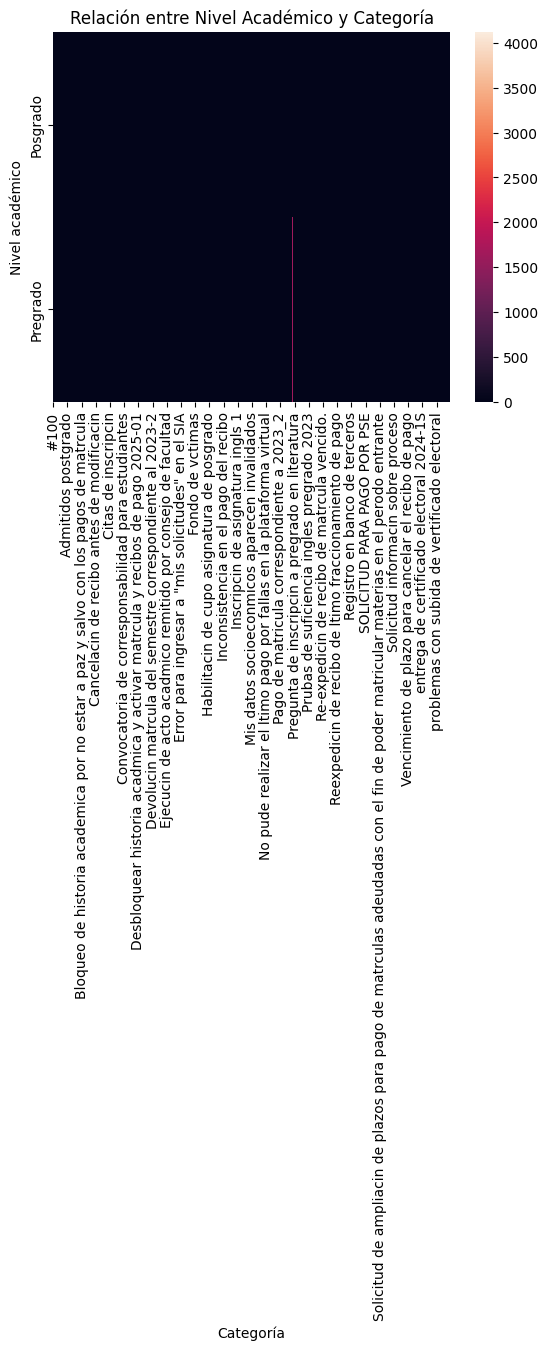

In [ ]:
import seaborn as sns

cross = pd.crosstab(df['Nivel'], df['Seleccione la categoría de su consulta'])

sns.heatmap(cross, annot=False)
plt.title('Relación entre Nivel Académico y Categoría')
plt.xlabel('Categoría')
plt.ylabel('Nivel académico')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os

sns.set(style="whitegrid")

In [ ]:
# ===============================
# CONFIGURACIÓN
# ===============================

print("Shape del dataset:", df.shape)
print("\nColumnas:")
print(df.columns)

Shape del dataset: (36468, 12)

Columnas:
Index(['Marca temporal', 'LLave', 'Plan de estudios', 'Facultad', 'Nivel',
       'Seleccione la categoría de su consulta',
       '¿Con la información que se le ha expuesto se ha resuelto su consulta?',
       'Por favor indique el detalle de su consulta', 'RESPUESTA DEL CASO',
       'ESTADO SOLICITUD', 'SEMESTRE ', 'PLAN_ESTANDAR'],
      dtype='object')


In [ ]:
# ===============================
# LIMPIEZA DE COLUMNAS
# ===============================

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:

# ===============================
# MÉTRICAS GENERALES
# ===============================

print("\n===== INFO DATASET =====")
print(df.info())

print("\n===== ESTADÍSTICAS =====")
print(df.describe(include='all'))


===== INFO DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36468 entries, 0 to 36467
Data columns (total 12 columns):
 #   Column                                                                 Non-Null Count  Dtype         
---  ------                                                                 --------------  -----         
 0   marca_temporal                                                         36468 non-null  datetime64[ns]
 1   llave                                                                  36468 non-null  object        
 2   plan_de_estudios                                                       36462 non-null  object        
 3   facultad                                                               36468 non-null  object        
 4   nivel                                                                  36468 non-null  object        
 5   seleccione_la_categoría_de_su_consulta                                 36466 non-null  object        
 6   ¿con


Valores nulos:
respuesta_del_caso                                                       2936
semestre                                                                 2015
por_favor_indique_el_detalle_de_su_consulta                              1298
plan_de_estudios                                                            6
plan_estandar                                                               6
seleccione_la_categoría_de_su_consulta                                      2
marca_temporal                                                              0
llave                                                                       0
facultad                                                                    0
nivel                                                                       0
¿con_la_información_que_se_le_ha_expuesto_se_ha_resuelto_su_consulta?       0
estado_solicitud                                                            0
dtype: int64


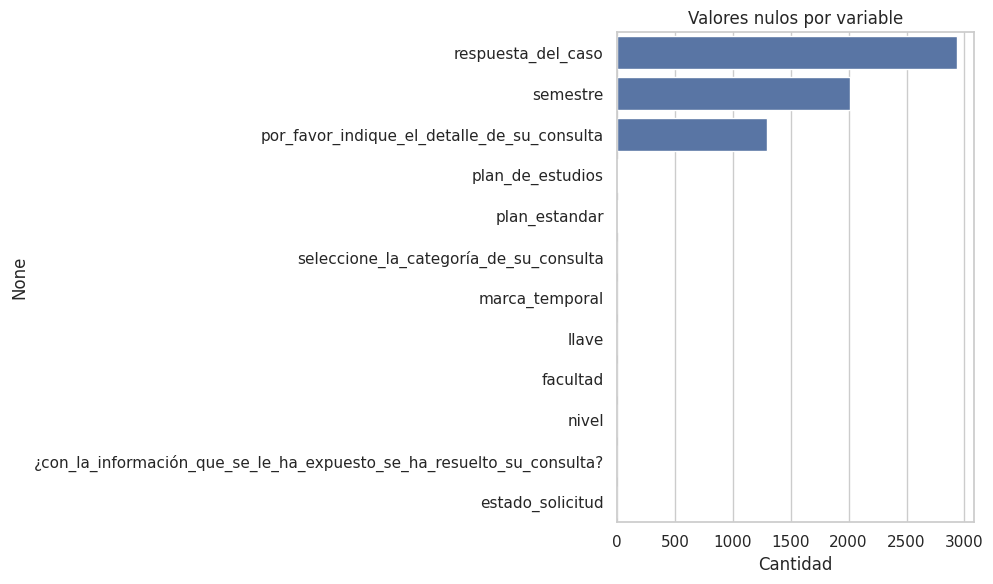

In [ ]:
# ===============================
# VALORES NULOS
# ===============================

missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Valores nulos por variable")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.savefig("valores_nulos.png")

print("\nValores nulos:")
print(missing)

In [ ]:

# ===============================
# DUPLICADOS
# ===============================

duplicates = df.duplicated().sum()

print("\nFilas duplicadas:", duplicates)


Filas duplicadas: 0


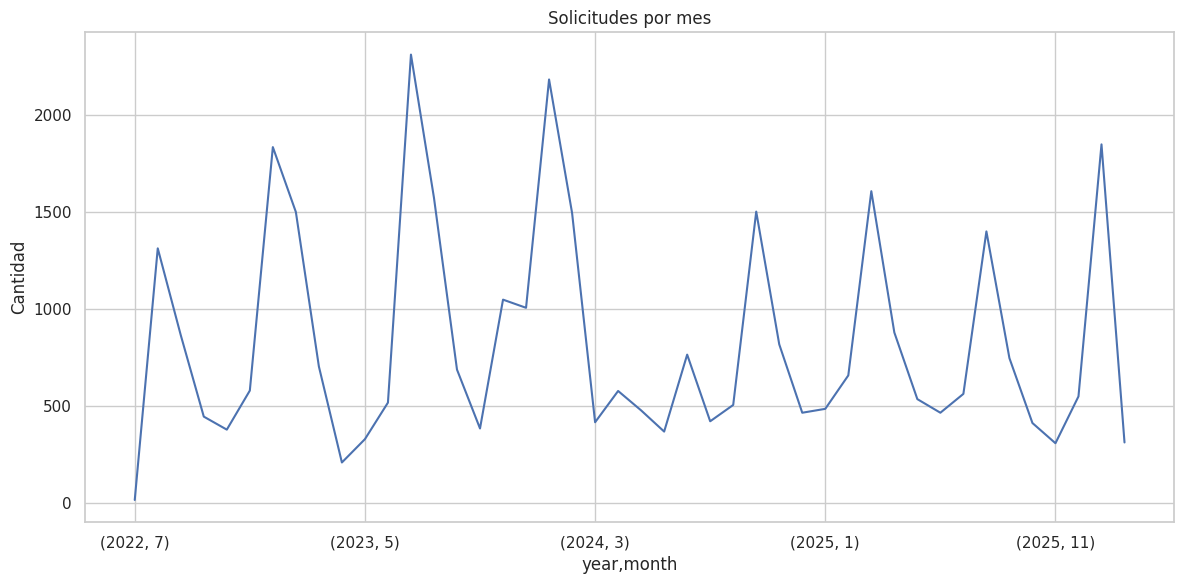

In [ ]:
# ===============================
# ANÁLISIS TEMPORAL
# ===============================

if "marca_temporal" in df.columns:

    df["marca_temporal"] = pd.to_datetime(df["marca_temporal"], errors="coerce")

    df["year"] = df["marca_temporal"].dt.year
    df["month"] = df["marca_temporal"].dt.month

    temporal = df.groupby(["year","month"]).size()

    plt.figure(figsize=(12,6))
    temporal.plot()
    plt.title("Solicitudes por mes")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.savefig("solicitudes_por_mes.png")

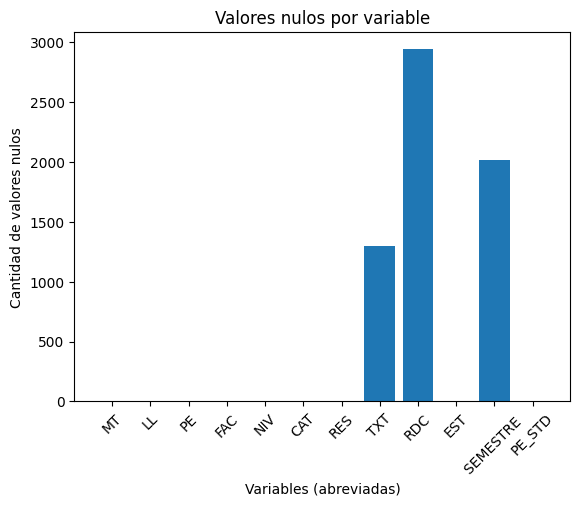

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Conteo de nulos
null_counts = df.isnull().sum()

# Crear abreviaturas
abbrev_map = {
    'Marca temporal': 'MT',
    'LLave': 'LL',
    'Plan de estudios': 'PE',
    'Facultad': 'FAC',
    'Nivel': 'NIV',
    'Seleccione la categoría de su consulta': 'CAT',
    '¿Con la información que se le ha expuesto se ha resuelto su consulta?': 'RES',
    'Por favor indique el detalle de su consulta': 'TXT',
    'RESPUESTA DEL CASO': 'RDC',
    'ESTADO SOLICITUD': 'EST',
    'SEMESTRE': 'SEM',
    'PLAN_ESTANDAR': 'PE_STD'
}

# Aplicar abreviaturas
labels = [abbrev_map.get(col, col) for col in null_counts.index]

# Graficar
plt.figure()
plt.bar(labels, null_counts.values)

plt.xlabel('Variables (abreviadas)')
plt.ylabel('Cantidad de valores nulos')
plt.title('Valores nulos por variable')

plt.xticks(rotation=45)
plt.show()

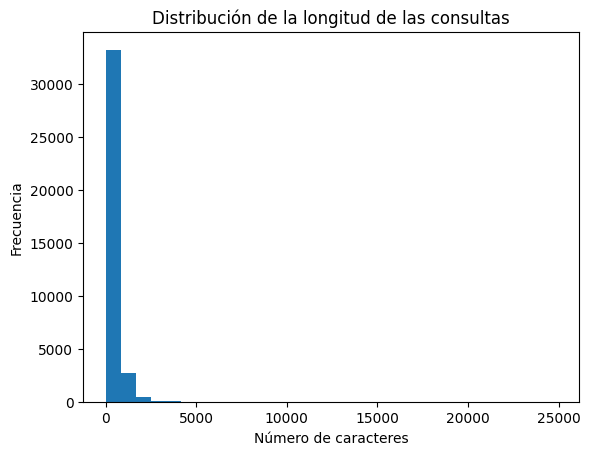

In [ ]:
df['longitud_texto'] = df['Por favor indique el detalle de su consulta'].astype(str).apply(len)

df['longitud_texto'].plot(kind='hist', bins=30)
plt.title('Distribución de la longitud de las consultas')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.show()

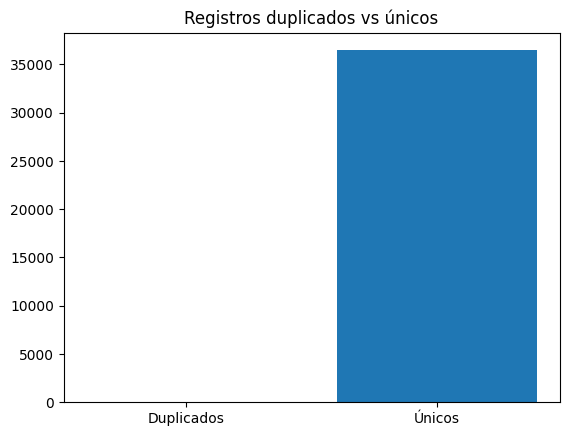

In [ ]:
duplicados = df.duplicated().sum()

plt.bar(['Duplicados', 'Únicos'], [duplicados, len(df)-duplicados])
plt.title('Registros duplicados vs únicos')
plt.show()

La gráfica muestra la evolución mensual del número de solicitudes académicas registradas en el sistema. Permite analizar patrones temporales de demanda.

1. Comportamiento cíclico

Se observa un patrón repetitivo cada año: existen meses con picos muy altos de solicitudes, seguidos de periodos de baja actividad.

Esto sugiere que las consultas no ocurren de forma uniforme, sino que están asociadas al calendario académico.

2. Meses con mayor volumen de solicitudes

En varios puntos de la serie se presentan picos superiores a 2000 solicitudes mensuales.

Estos picos probablemente coinciden con momentos como:

inicio de semestre

procesos de matrícula

inscripciones académicas

solicitud de certificados

procesos administrativos estudiantiles

Estos periodos generan mayor carga operativa para la ventanilla académica.

3. Meses de menor actividad

También se observan meses con valores cercanos a 300–500 solicitudes.

Estos periodos pueden corresponder a:

vacaciones académicas

semanas intersemestrales

periodos sin procesos administrativos relevantes

Esto confirma que la demanda fluctúa según el calendario institucional.

4. Tendencia general

No se observa una tendencia clara de crecimiento o decrecimiento a largo plazo, sino más bien variaciones periódicas.

Esto indica que el volumen de solicitudes está determinado principalmente por factores académicos estacionales.

5. Implicaciones para el sistema de clasificación automática

Este comportamiento tiene implicaciones importantes:

En los meses pico el sistema recibe un volumen alto de consultas.

La clasificación automática de solicitudes puede ayudar a reducir tiempos de respuesta en estos periodos.

El modelo NLP podría integrarse para gestionar automáticamente el alto flujo de consultas.

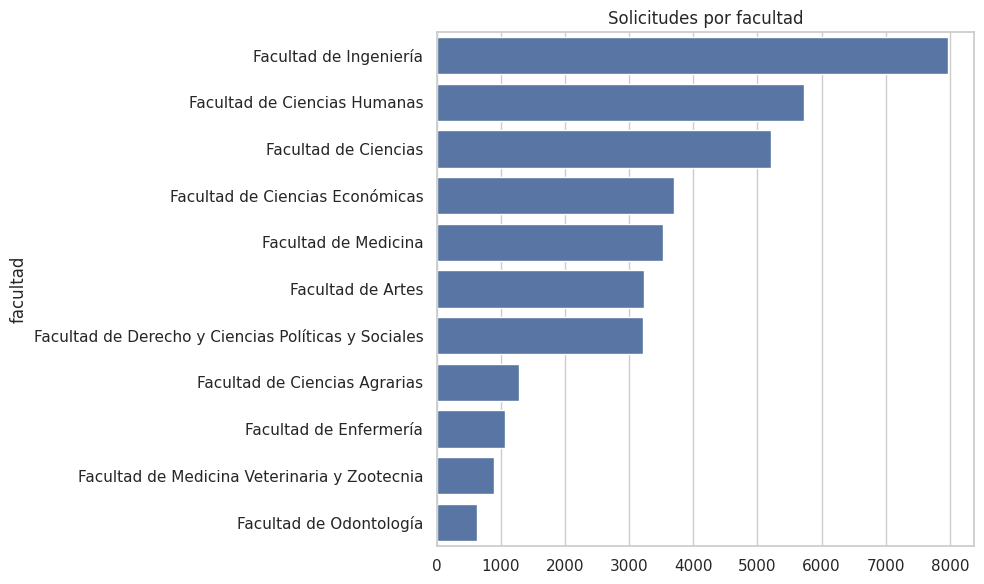

In [ ]:
# ===============================
# DISTRIBUCIÓN POR FACULTAD
# ===============================

if "facultad" in df.columns:

    facultad_counts = df["facultad"].value_counts().head(15)

    plt.figure(figsize=(10,6))
    sns.barplot(y=facultad_counts.index, x=facultad_counts.values)
    plt.title("Solicitudes por facultad")
    plt.tight_layout()
    plt.savefig("facultad_distribucion.png")

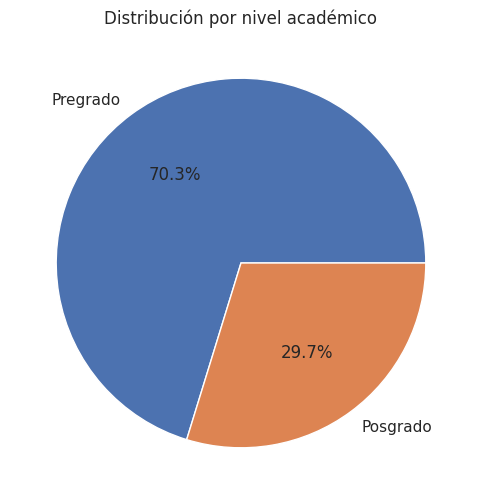

In [ ]:
# ===============================
# DISTRIBUCIÓN POR NIVEL
# ===============================

if "nivel" in df.columns:

    nivel_counts = df["nivel"].value_counts()

    plt.figure(figsize=(6,6))
    plt.pie(nivel_counts.values,
            labels=nivel_counts.index,
            autopct='%1.1f%%')

    plt.title("Distribución por nivel académico")
    plt.savefig("nivel_pie.png")

In [ ]:
# ===============================
# DISTRIBUCIÓN POR CATEGORÍA
# ===============================

categoria_col = None


for col in df.columns:
    if "categoria" in col:
        categoria_col = col

if categoria_col:

    categoria_counts = df[categoria_col].value_counts().head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(y=categoria_counts.index, x=categoria_counts.values)
    plt.title("Top categorías de consultas")
    plt.tight_layout()
    plt.savefig("categorias.png")


Estadísticas longitud texto
count    36468.000000
mean       389.550483
std        444.469935
min          1.000000
25%        149.000000
50%        287.000000
75%        493.000000
max      24887.000000
Name: longitud_texto, dtype: float64


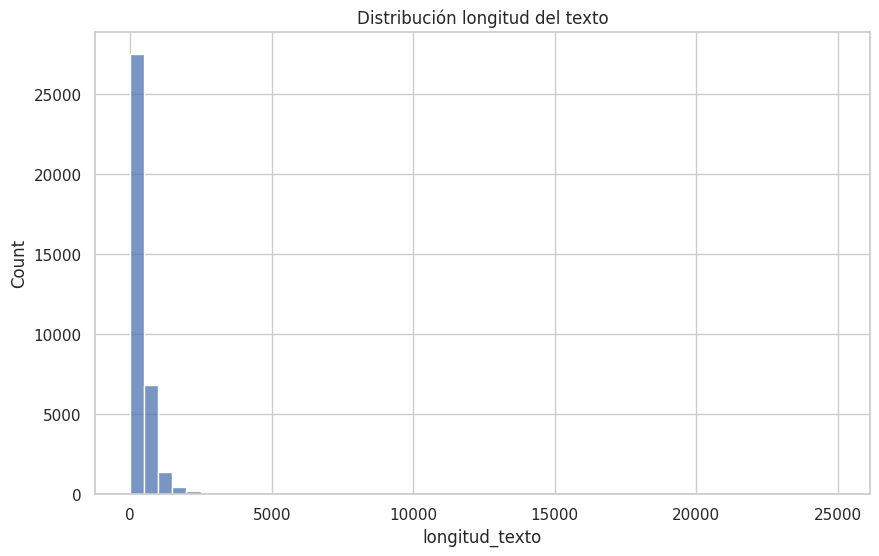

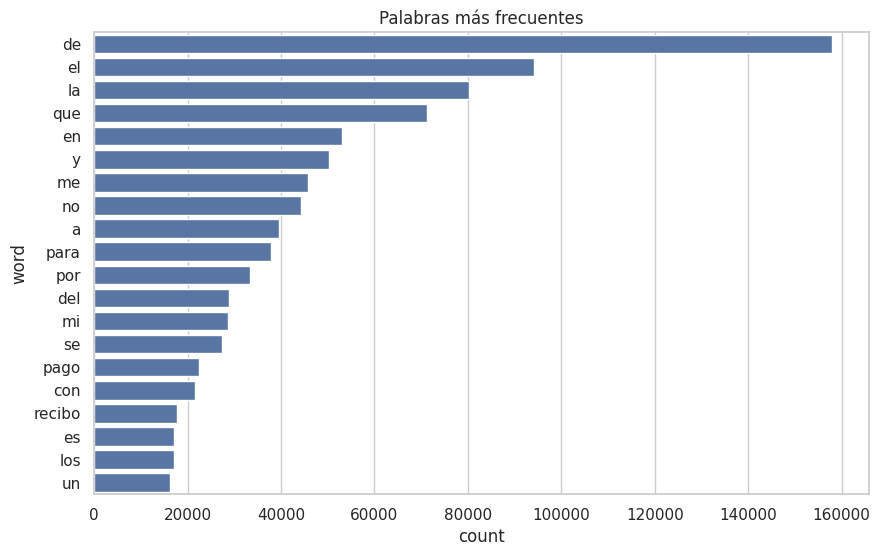

In [ ]:
# ===============================
# ANÁLISIS TEXTO
# ===============================

texto_col = None

for col in df.columns:
    if "detalle" in col:
        texto_col = col

if texto_col:

    text_data = df[texto_col].dropna()

    # longitud del texto
    df["longitud_texto"] = df[texto_col].astype(str).apply(len)

    plt.figure(figsize=(10,6))
    sns.histplot(df["longitud_texto"], bins=50)
    plt.title("Distribución longitud del texto")
    plt.savefig("longitud_texto.png")

    print("\nEstadísticas longitud texto")
    print(df["longitud_texto"].describe())

    # palabras frecuentes

    text = " ".join(text_data.astype(str))

    words = re.findall(r'\w+', text.lower())

    word_freq = Counter(words)

    common_words = word_freq.most_common(20)

    words_df = pd.DataFrame(common_words,
                            columns=["word","count"])

    plt.figure(figsize=(10,6))
    sns.barplot(y="word", x="count", data=words_df)
    plt.title("Palabras más frecuentes")
    plt.savefig("palabras_frecuentes.png")

In [ ]:
import nltk
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words("spanish"))

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return palabras

# Aplicar limpieza
tokens = df["por_favor_indique_el_detalle_de_su_consulta"].apply(limpiar_texto)

# Unir todas las palabras
todas_palabras = [palabra for lista in tokens for palabra in lista]

# Contar frecuencia
frecuencia = Counter(todas_palabras).most_common(20)

palabras_df = pd.DataFrame(frecuencia, columns=["palabra","frecuencia"])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/tmp/ipykernel_519/537370272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


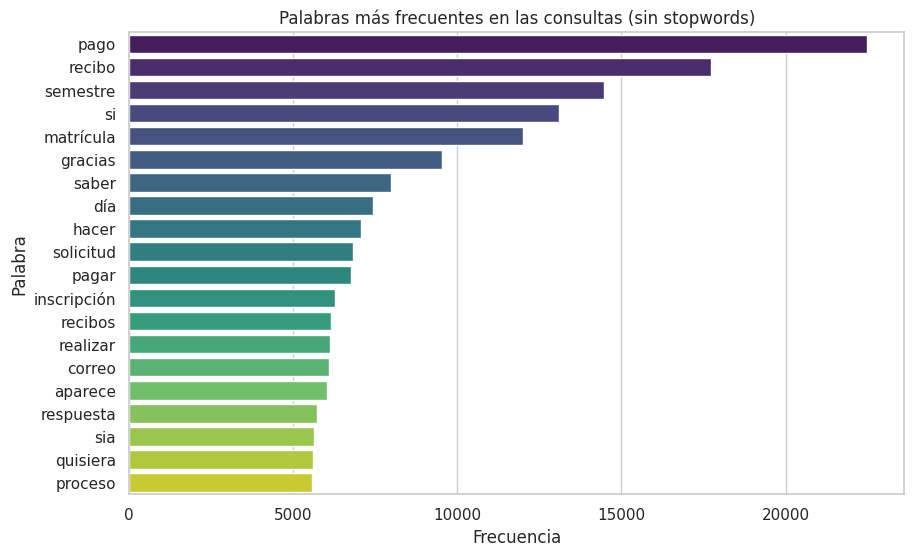

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=palabras_df,
    x="frecuencia",
    y="palabra",
    palette="viridis"
)

plt.title("Palabras más frecuentes en las consultas (sin stopwords)")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")

plt.show()

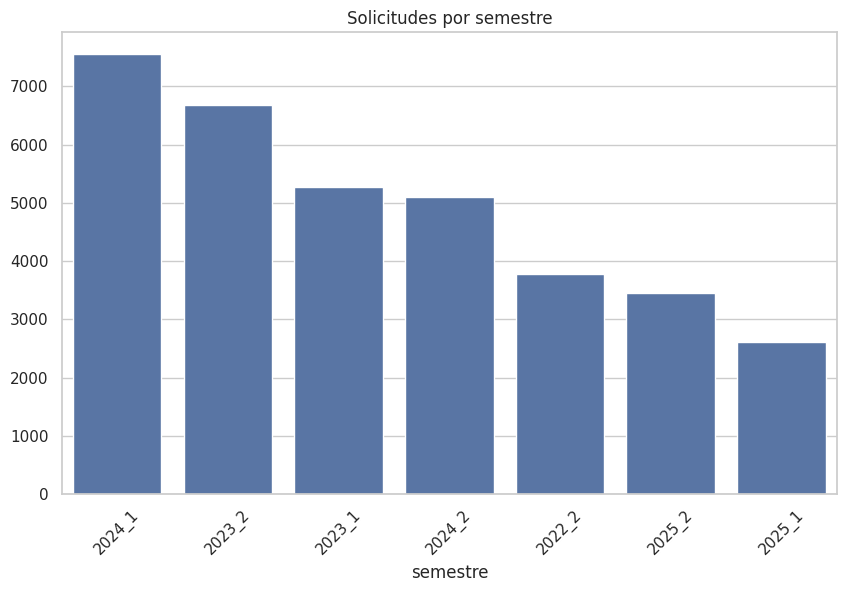

In [ ]:
# ===============================
# DISTRIBUCIÓN POR SEMESTRE
# ===============================

if "semestre" in df.columns:

    semestre_counts = df["semestre"].value_counts()

    plt.figure(figsize=(10,6))
    sns.barplot(x=semestre_counts.index, y=semestre_counts.values)
    plt.xticks(rotation=45)
    plt.title("Solicitudes por semestre")
    plt.savefig("semestre.png")


Análisis completado.


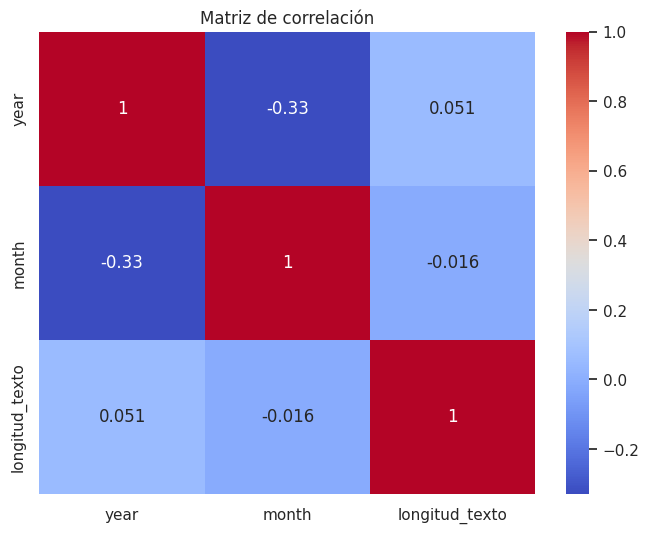

In [ ]:
# ===============================
# CORRELACIONES
# ===============================

numeric_cols = df.select_dtypes(include=np.number)

if len(numeric_cols.columns) > 1:

    corr = numeric_cols.corr()

    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Matriz de correlación")
    plt.savefig("correlacion.png")

print("\nAnálisis completado.")

## Distribución por estado de la solicitud

Analiza si las solicitudes están:

resueltas
en proceso
cerradas

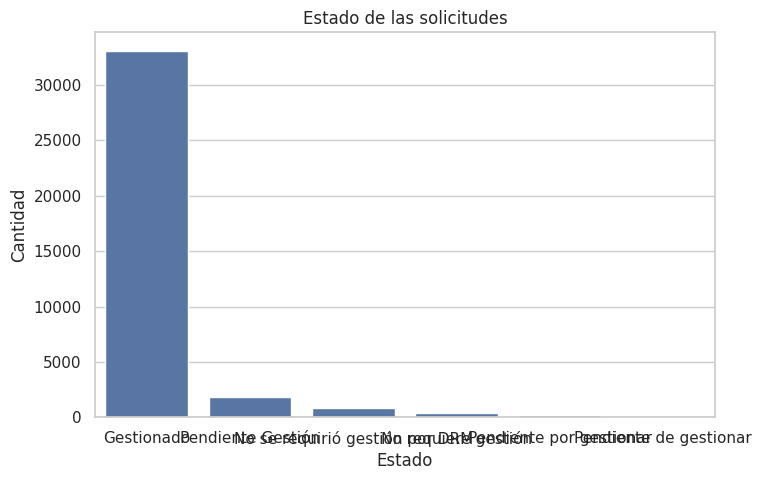

estado_solicitud
Gestionado                        33110
Pendiente Gestión                  1847
No se requirió gestión por DRM      872
No requiere gestión                 424
Pendiente por gestionar             211
Pendiente de gestionar                4
Name: count, dtype: int64


In [ ]:
estado_counts = df["estado_solicitud"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=estado_counts.index, y=estado_counts.values)

plt.title("Estado de las solicitudes")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.show()

print(estado_counts)

## Distribución de categorías de consulta

Esta es una de las variables más importantes porque será la variable objetivo del modelo de clasificación.

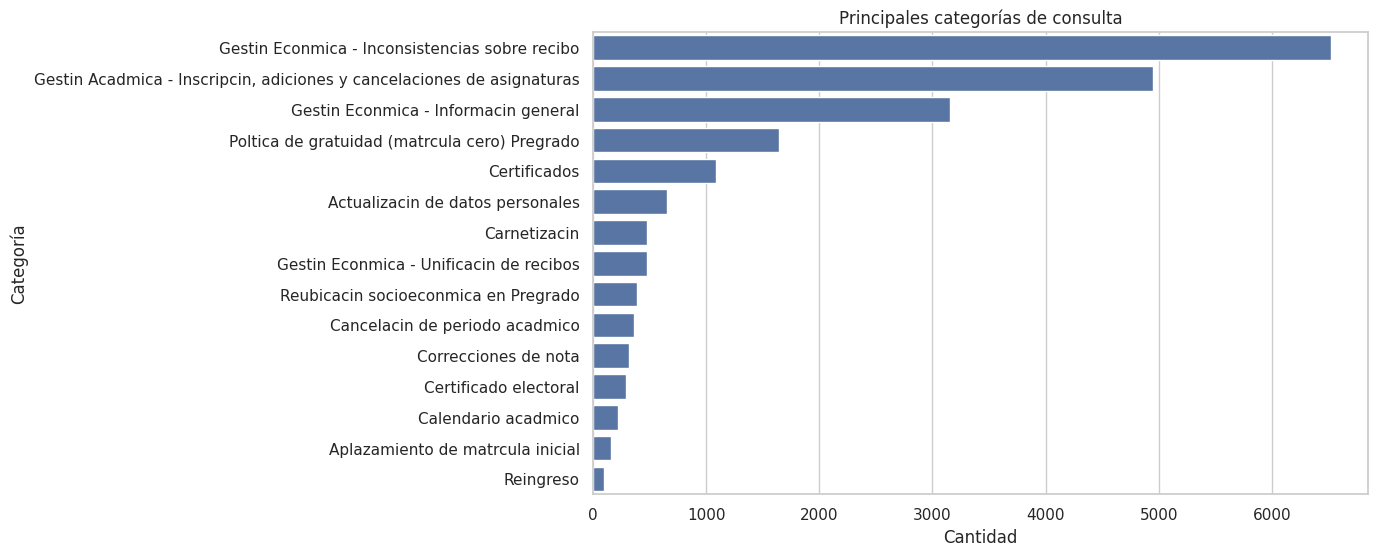

seleccione_la_categoría_de_su_consulta
Gestin Econmica - Inconsistencias sobre recibo                            6524
Gestin Acadmica - Inscripcin, adiciones y cancelaciones de asignaturas    4952
Gestin Econmica - Informacin general                                      3152
Poltica de gratuidad (matrcula cero) Pregrado                             1642
Certificados                                                              1084
Actualizacin de datos personales                                           650
Carnetizacin                                                               478
Gestin Econmica - Unificacin de recibos                                    477
Reubicacin socioeconmica en Pregrado                                       388
Cancelacin de periodo acadmico                                             366
Correcciones de nota                                                       322
Certificado electoral                                                      293
Calendario ac

In [ ]:
categoria_counts = df["seleccione_la_categoría_de_su_consulta"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=categoria_counts.values, y=categoria_counts.index)

plt.title("Principales categorías de consulta")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
plt.show()

print(categoria_counts)

## Distribución de planes de estudio

Esta variable puede tener muchas categorías, por lo que conviene mostrar solo las más frecuentes.

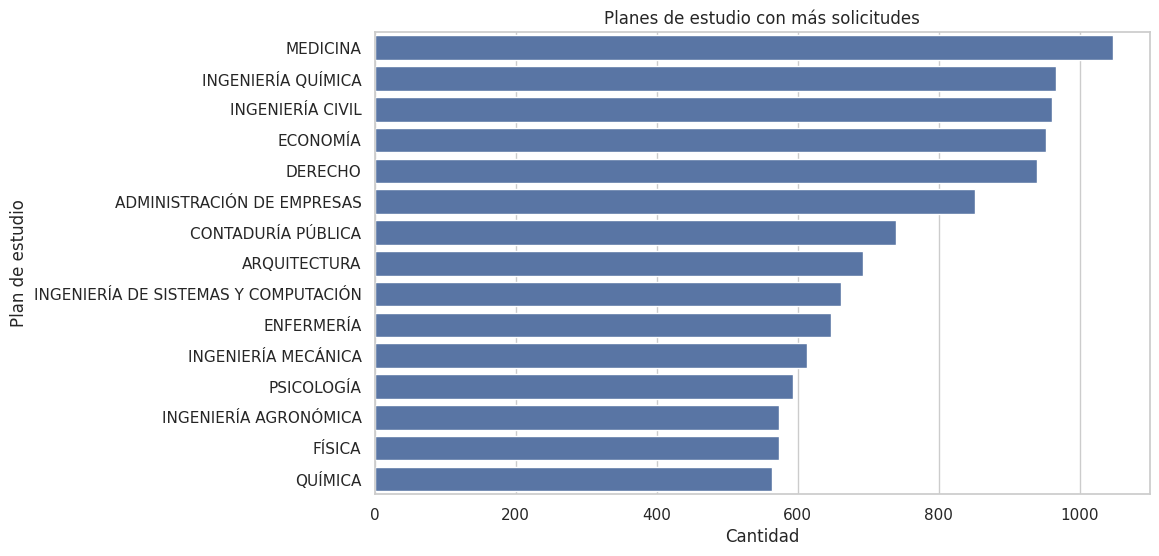

In [ ]:
plan_counts = df["plan_estandar"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=plan_counts.values, y=plan_counts.index)

plt.title("Planes de estudio con más solicitudes")
plt.xlabel("Cantidad")
plt.ylabel("Plan de estudio")
plt.show()

In [ ]:
df["facultad"].value_counts(normalize=True)*100

,proportion
facultad,
Facultad de Ingeniería,21.868487
Facultad de Ciencias Humanas,15.706921
Facultad de Ciencias,14.278271
Facultad de Ciencias Económicas,10.156850
Facultad de Medicina,9.657782
Facultad de Artes,8.857080
Facultad de Derecho y Ciencias Políticas y Sociales,8.815948
Facultad de Ciencias Agrarias,3.520895
Facultad de Enfermería,2.936821


# Análisis de relaciones entre variables